**Katherine Liu   0493441057   katherine.ljw@icloud.com**

**KPay BA Intern Case Study**

In [1]:
# Data processing
import pandas as pd
import numpy as np
import re
import string
import time

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown

# Google Maps API
import googlemaps

In [2]:
# Read the raw data
raw_path = 'Case Study.csv'
df_raw = pd.read_csv(raw_path)

print('Number of rows in raw data:', len(df_raw))
print('Columns in raw data:', list(df_raw.columns))
df_raw.head()

Number of rows in raw data: 199999
Columns in raw data: ['id', 'lead_key', 'phone', 'business_name', 'state', 'suburb', 'address', 'sector_level_1', 'sector_level_2', 'sector_level_3']


/var/folders/j5/g8rtd11j6fq47kc3b_pt23h00000gn/T/ipykernel_79673/1005256100.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(raw_path)


,id,lead_key,phone,business_name,state,suburb,address,sector_level_1,sector_level_2,sector_level_3
0,2312630,L_611287243333,6.11287E+11,PRO IT,NSW,sydney,"Suite 604, Level 6/83 York Street Sydney NSW 2000",Retail,Electronics & Appliances,"Computer, IT Technical Support"
1,2312631,L_611300048153,6.113E+11,Hoist Care,NSW,sydney,Sydney Sydney NSW 2000,Retail,Fashion & Accessories,"Wholesale Car Accessories, Manufacturers"
2,2312632,L_611300053384,6.113E+11,JEEVI,NSW,sydney,714/368 Sussex Street Sydney NSW 2000,Beauty & Wellness,Others,Community Health Services
3,2312633,L_611300069313,6.113E+11,Dunlap Bike Finance,NSW,sydney,377 Kent St Sydney NSW 2000,Retail,Fashion & Accessories,"Wholesale Motorcycle Parts and Accessories, Ma..."
4,2312634,L_611300074353,6.113E+11,Metiri Mensus,NSW,parramatta,Suite 107 L 1 30 Cowper Street Parramatta NSW...,F&B,Others,Food


In [3]:
# Data quality check: missing values, duplicates, sample records

print('Missing values per column:')
print(df_raw.isna().sum())

Missing values per column:
id                     0
lead_key               0
phone                  0
business_name          9
state               8335
suburb            104717
address               54
sector_level_1     37770
sector_level_2     37770
sector_level_3      6846
dtype: int64


# Part 1: Data Cleaning Pipeline

The data cleaning process is applied on a copy of the raw dataset (`df_clean`) to preserve the original data. Each step standardizes, validates, and removes invalid entries in specific columns.


## Step 0: Initialize the Cleaning Table
- Copy the raw dataset to `df_clean`.
- All subsequent cleaning operations are applied to this copy.
- **Output:** Initial number of rows recorded for reference.


## Step 1: Clean and Validate `phone`
- Remove spaces and special characters (`+`, `-`, `(`, `)`, `.`), keeping only digits.
- Apply Australian phone rules:
  - 9 digits starting with `4` → mobile
  - 10 digits starting with `04` → domestic mobile
  - 12 digits starting with `6104` → international mobile (+61)
  - 11 digits starting with `61` → fixed line (+61)
  - 10 digits starting with `0` → domestic landline
- Rows not matching any rule are removed.
- **Output:** Number of rows after phone validation.


## Step 2: Clean `business_name`
- Remove missing values (`NaN`).
- Remove names consisting only of numbers.
- Remove names consisting only of punctuation or spaces.
- Remove obvious garbled text caused by incorrect encoding (UTF-8 decoded as Latin-1).
- **Output:** Number of rows after business name cleaning.


## Step 3: Standardize and Filter `state`
- Convert all state values to uppercase and trim whitespace.
- Map full state names to 2-letter abbreviations:
  - `NEW SOUTH WALES` → `NSW`
  - `VICTORIA` → `VIC`
  - `QUEENSLAND` → `QLD`
  - `WESTERN AUSTRALIA` → `WA`
  - `SOUTH AUSTRALIA` → `SA`
  - `TASMANIA` → `TAS`
  - `AUSTRALIAN CAPITAL TERRITORY` → `ACT`
  - `NORTHERN TERRITORY` → `NT`
- Keep only the 8 official Australian states/territories.
- **Output:** Number of rows after state standardization and filtering.


## Step 4: Standardize `suburb` and Industry Classification
### Suburb:
- Trim spaces, normalize casing (title case), and replace multiple spaces with single space.
- Remove missing suburbs.
- Remove suburbs that do not start with a letter.

### Industry Columns (`sector_level_1`, `sector_level_2`, `sector_level_3`):
- Trim leading and trailing spaces for consistency.

- **Output:** Number of rows after suburb and industry column cleaning.


## Step 5: Clean `address`
- Remove leading/trailing spaces and punctuation.
- Merge multiple spaces into a single space.
- Remove missing addresses and addresses consisting only of punctuation.
- Remove addresses shorter than 10 characters.
- **Output:** Number of rows after address cleaning.


## Step 6: Standardize `sector_level_3`
- Trim spaces and convert to string.
- Remove leading `$` symbols.
- Remove punctuation from the text.
- **Output:** Number of rows after `sector_level_3` cleaning.


## Step 7: Remove Duplicates and Export
- Remove duplicate rows:
  - Preferably using `lead_key`.
  - If missing, deduplicate by `business_name` + `address`.
  - Otherwise, remove exact duplicates.
- Save the cleaned dataset to `Case Study_cleaned.csv`.
- **Output:** Final number of rows and confirmation of export.


## **Summary:**  
This pipeline ensures:
1. Phone numbers, addresses, suburbs, and business names are valid.
2. State values are standardized to official abbreviations.
3. Industry categories are cleaned and formatted.
4. Duplicate entries are removed.
5. The cleaned dataset is ready for further analysis or processing.

In [4]:
# Step 0: Initialize the cleaning table
# Copy the raw dataframe to df_clean; all cleaning operations will be performed on this copy

df_clean = df_raw.copy()
print("Rule 0: Initial number of rows:", len(df_clean))

Rule 0: Initial number of rows: 199999


In [5]:
# Step 1: Clean `phone` according to Australian phone number rules
# Rules:
# - 9 digits starting with 4 (mobile without leading 0)
# - 10 digits starting with 04 (domestic mobile)
# - 12 digits starting with 6104 (+61 04XXXXXXX)
# - 11 digits starting with 61 (+61 XXXXXXXXX landline)
# - 10 digits starting with 0 (domestic landline)

def clean_and_validate_phone(x: object) -> object:
    if pd.isna(x):
        return np.nan
    s = str(x)
    for ch in [" ", "(", ")", "+", "-", "."]:
        s = s.replace(ch, "")
    s = "".join(ch for ch in s if ch.isdigit())
    if not s:
        return np.nan
    if len(s) == 9 and s.startswith("4"):
        return s
    if len(s) == 10 and s.startswith("04"):
        return s
    if len(s) == 12 and s.startswith("6104"):
        return s
    if len(s) == 11 and s.startswith("61"):
        return s
    if len(s) == 10 and s.startswith("0"):
        return s
    return np.nan

if "phone" in df_clean.columns:
    before = len(df_clean)
    if "phone_normalized" in df_clean.columns:
        df_clean = df_clean.drop(columns=["phone_normalized"])
    df_clean["phone"] = df_clean["phone"].apply(clean_and_validate_phone)
    df_clean = df_clean[df_clean["phone"].notna()].copy()
    print("Rule 1: Number of rows after phone cleaning:", len(df_clean), "(before:", before, ")")
else:
    print("Rule 1: `phone` column not found, skipped.")

Rule 1: Number of rows after phone cleaning: 187183 (before: 199999 )


In [6]:
# Step 2: Clean invalid business names (`business_name`)
# Rules:
# 1. Remove missing values (NaN)
# 2. Remove names consisting only of punctuation or spaces
# 3. Remove names consisting only of numbers
# 4. Remove obviously garbled text (e.g., UTF-8 decoded as Latin-1 producing characters like æ, Ã, ½)
#    A string is considered garbled if the proportion of extended Latin-1 characters (ASCII >127) is too high

def is_mojibake(s: str) -> bool:
    latin1_chars = sum(1 for c in s if 128 <= ord(c) <= 255)
    return latin1_chars / len(s) > 0.3


def is_valid_business_name(x: object) -> bool:
    if pd.isna(x):
        return False
    
    s = str(x).strip()
    
    if not s:
        return False
    
    # Only digits
    if s.isdigit():
        return False
    
    # Only punctuation or spaces
    stripped = "".join(ch for ch in s if ch not in string.punctuation and not ch.isspace())
    if not stripped:
        return False
    
    # Detect garbled text
    if is_mojibake(s):
        return False
    
    return True


if "business_name" in df_clean.columns:
    before = len(df_clean)
    df_clean = df_clean[df_clean["business_name"].apply(is_valid_business_name)].copy()
    print("Rule 2: Number of rows after cleaning business_name:", len(df_clean), "(before:", before, ")")
else:
    print("Rule 2: `business_name` column not found, skipped.")

Rule 2: Number of rows after cleaning business_name: 186882 (before: 187183 )


In [7]:
# Step 3: Standardize and filter `state` (keep only the 8 Australian states/territories)

allowed_states = {"NSW", "VIC", "QLD", "WA", "SA", "TAS", "ACT", "NT"}
state_full_to_abbr = {
    "NEW SOUTH WALES": "NSW",
    "VICTORIA": "VIC",
    "QUEENSLAND": "QLD",
    "WESTERN AUSTRALIA": "WA",
    "SOUTH AUSTRALIA": "SA",
    "TASMANIA": "TAS",
    "AUSTRALIAN CAPITAL TERRITORY": "ACT",
    "NORTHERN TERRITORY": "NT",
}

def normalize_state_value(x: object) -> object:
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    if s in state_full_to_abbr:
        s = state_full_to_abbr[s]
    if s in allowed_states:
        return s
    return np.nan

if "state" in df_clean.columns:
    before = len(df_clean)
    df_clean["state"] = df_clean["state"].apply(normalize_state_value)
    df_clean = df_clean[df_clean["state"].notna()].copy()
    print("Rule 3: Number of rows after state standardization and filtering:", len(df_clean), "(before:", before, ")")
else:
    print("Rule 3: `state` column not found, skipped.")

Rule 3: Number of rows after state standardization and filtering: 186707 (before: 186882 )


In [8]:
# Step 4: Standardize `suburb` and industry classification text format
# Rules:
# - Normalize case and whitespace
# - Remove missing suburb values
# - Remove suburbs that do not start with a letter

if "suburb" in df_clean.columns:
    before = len(df_clean)
    df_clean["suburb"] = (
        df_clean["suburb"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
        .str.title()
    )
    # Treat 'nan'/'NaN'/'None' as missing
    df_clean["suburb"] = df_clean["suburb"].replace({"nan": np.nan, "NaN": np.nan, "None": np.nan})
    # Remove missing suburb
    df_clean = df_clean[df_clean["suburb"].notna()].copy()
    # Remove suburbs not starting with a letter (ignore leading spaces)
    df_clean = df_clean[df_clean["suburb"].str.match(r"^[A-Za-z].*")].copy()
    print("Rule 3-suburb: Number of rows after cleaning suburb:", len(df_clean), "(before:", before, ")")
else:
    print("Rule 3-suburb: `suburb` column not found, skipped.")

# Trim leading/trailing spaces in industry columns
for col in ["sector_level_1", "sector_level_2", "sector_level_3"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip()

print("Rule 4-sector: Number of rows after standardizing industry columns:", len(df_clean))

Rule 3-suburb: Number of rows after cleaning suburb: 186405 (before: 186707 )
Rule 4-sector: Number of rows after standardizing industry columns: 186405


In [9]:
# Step 5: Clean `address` based on logical rules
# Rules:
# - Remove missing addresses
# - Remove addresses containing only punctuation or spaces
# - Remove addresses shorter than 10 characters
# - Standardize each cell by removing leading/trailing spaces and punctuation

if "address" in df_clean.columns:
    before = len(df_clean)

    df_clean["address"] = (
        df_clean["address"]
        .astype(str)
        .str.strip()  # Remove leading/trailing spaces
        .str.strip(string.punctuation)  # Remove leading/trailing punctuation
        .str.replace(r"\s+", " ", regex=True)  # Merge multiple spaces
    )

    # Treat 'nan'/'NaN'/'None' as missing
    df_clean["address"] = df_clean["address"].replace(
        {"nan": np.nan, "NaN": np.nan, "None": np.nan}
    )

    # Remove missing addresses
    df_clean = df_clean[df_clean["address"].notna()].copy()

    def valid_address(s: str) -> bool:
        if not s:
            return False

        stripped = "".join(ch for ch in s if not ch.isspace())

        # Remove addresses with only punctuation
        if stripped and all(ch in string.punctuation for ch in stripped):
            return False

        # Remove addresses shorter than 10 characters
        if len(s) < 10:
            return False

        return True

    df_clean = df_clean[df_clean["address"].apply(valid_address)].copy()

    print("Rule 5: Number of rows after address cleaning:", len(df_clean), "(before:", before, ")")

else:
    print("Rule 5: `address` column not found, skipped.")

Rule 5: Number of rows after address cleaning: 186329 (before: 186405 )


In [10]:
# Step 6: Standardize `sector_level_3`
if "sector_level_3" in df_clean.columns:
    # Convert to string and strip leading/trailing spaces
    df_clean["sector_level_3"] = df_clean["sector_level_3"].astype(str).str.strip()

    # Remove leading `$` symbol
    df_clean["sector_level_3"] = df_clean["sector_level_3"].str.lstrip('$')

    # Remove punctuation characters
    # string.punctuation contains !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
    df_clean["sector_level_3"] = df_clean["sector_level_3"].apply(
        lambda x: ''.join(ch for ch in x if ch not in string.punctuation)
    )

    print("Rule 6: `sector_level_3` cleaning completed, number of rows:", len(df_clean), "(before:", before, ")")
else:
    print("Rule 6: `sector_level_3` column not found, skipped.")

Rule 6: `sector_level_3` cleaning completed, number of rows: 186329 (before: 186405 )


In [11]:
# Step 7: Remove duplicates and export the final cleaned dataset
# Rules:
# - Preferably by `lead_key`
# - Otherwise by `business_name` + `address`

before = len(df_clean)
if "lead_key" in df_clean.columns:
    df_clean = df_clean.drop_duplicates(subset=["lead_key"])
elif {"business_name", "address"}.issubset(df_clean.columns):
    df_clean = df_clean.drop_duplicates(subset=["business_name", "address"])
else:
    df_clean = df_clean.drop_duplicates()

print("Rule 7: Number of rows after deduplication:", len(df_clean), "(before:", before, ")")

# Export to CSV
clean_path = "Case Study_cleaned.csv"
df_clean.to_csv(clean_path, index=False)
print(f"Final cleaned data saved to: {clean_path}")
print("Final number of rows:", len(df_clean))

Rule 7: Number of rows after deduplication: 186329 (before: 186329 )
Final cleaned data saved to: Case Study_cleaned.csv
Final number of rows: 186329


# Part 1: Data Enrichment

After cleaning, performed **3 enrichment steps** to enhance the dataset:

## 1. Merchant Size Estimation

- **Objective:** Estimate the merchant size (`Small`, `Medium`, `Large`) based on `sector_level_1`.
- **Method:** Check for keywords associated with each size category:
  - **Large:** `restaurant`, `food`, `catering`, `coffee`, `beverage`, `desserts`, etc.
  - **Medium:** `retail`, `fashion`, `clothing`, `beauty`, `spa`, `electronics`, etc.
  - **Small:** Default if none of the above.
- **Output:** New column `merchant_size_estimate`.

## 2. Location Potential Assessment

- **Objective:** Assess potential of merchant location using `suburb`.
- **Method:** 
  - Map suburbs to a `location_tier` (`High`, `Medium`, `Low`) using a predefined dictionary.
  - Suburbs not listed are assigned `Low`.
- **Output:** New column `location_tier`.

## 3. Online Presence Score (Google Rating & Rating count)

- **Objective:** Evaluate merchant online presence.
- **Method:**
  1. Use Google Maps Places API.
  2. Target merchants: **Large size** & **High location tier**.
  3. Retrieve `rating` and `user_ratings_total` for each merchant.
  4. Batch processing with retries and progress saving.
- **Output:** New columns `google_rating` and `google_rating_count`.

## Merge Enrichment Results

- Merge Google API results back into the cleaned dataset using unique `id`.
- Final enriched dataset: `Case Study_cleaned_enriched.csv`.
- Now contains:
  - `merchant_size_estimate`
  - `location_tier`
  - `google_rating`
  - `google_rating_count`



## **Summary:**  
The dataset has been cleaned, standardized, deduplicated, and enriched with **merchant size**, **location potential**, and **online presence scores**, ready for analysis and modeling.

### 1. Merchant Size Estimation

In [12]:
# Load the cleaned dataset
df = pd.read_csv('Case Study_cleaned.csv')

# Get unique values of sector_level_1
unique_sectors = df['sector_level_1'].unique()
# print("Unique values in sector_level_1:")
# print(unique_sectors)

# Estimate merchant size based on sector_level_1
def estimate_merchant_size(sector):
    if pd.isna(sector):
        return 'Small'
    
    sector_str = str(sector).lower()
    
    # Large merchants
    large_keywords = ['restaurant', 'food', 'f&b', 'coffee', 'beverage', 'catering', 
                      'desserts', 'grocer', 'market', 'snack', 'ice cream', 'fruit', 'grocery']
    if any(k in sector_str for k in large_keywords):
        return 'Large'
    
    # Medium merchants
    medium_keywords = ['retail', 'fashion', 'clothing', 'beauty', 'wellness', 'spa', 'salon', 
                       'hair', 'electronics', 'furniture', 'toys', 'games', 'office', 'gift', 
                       'appliance', 'kitchen']
    if any(k in sector_str for k in medium_keywords):
        return 'Medium'
    
    # Default to Small
    return 'Small'

# Create a new column 'merchant_size_estimate'
df['merchant_size_estimate'] = df['sector_level_1'].apply(estimate_merchant_size)

# Display results
print(df[['sector_level_1', 'merchant_size_estimate']].head())

          sector_level_1 merchant_size_estimate
0                 Others                  Small
1  Professional Services                  Small
2                    F&B                  Large
3                 Others                  Small
4  Professional Services                  Small


### 2. Location Potential Assessment

In [13]:
# Get unique suburb values and print them
unique_suburbs = df['suburb'].unique()
print("All unique suburb names:")
# for suburb in unique_suburbs:
    # print(suburb)

# Define suburb -> location_tier mapping
location_tier_map = {
    'Sydney': 'High', 'Sydney CBD': 'High', 'North Sydney': 'High', 'Chatswood': 'High',
    'Parramatta': 'High', 'Haymarket': 'High', 'Ultimo': 'High', 'Pyrmont': 'High',
    'Bondi Junction': 'High', 'St Leonards': 'High', 'Crows Nest': 'High',
    'Macquarie Park': 'Medium', 'Burwood': 'Medium', 'Strathfield': 'Medium', 'Hornsby': 'Medium',
    'Dee Why': 'Medium', 'Neutral Bay': 'Medium', 'Ryde': 'Medium', 'Mascot': 'Medium',
    'Balmain': 'Medium', 'Glebe': 'Medium', 'Leichhardt': 'Medium', 'Marrickville': 'Medium',
    'Drummoyne': 'Medium', 'Rockdale': 'Medium', 'Kogarah': 'Medium', 'Blacktown': 'Medium',
    'Liverpool': 'Medium', 'Penrith': 'Medium', 'Campbelltown': 'Medium', 'Nowra': 'Medium',
    'Wollongong': 'Medium', 'Port Macquarie': 'Low', 'Lake Tabourie': 'Low', 'Kurrajong Hills': 'Low',
    'Kurri Kurri': 'Low', 'Lakesland': 'Low', 'Lavington': 'Low', 'Wentworth Falls': 'Low',
    'Lawson': 'Low', 'Wyoming': 'Low', 'Lismore': 'Low', 'Lithgow': 'Low', 'Jilliby': 'Low',
    'Woy Woy': 'Low', 'Magenta': 'Low', 'Bowral': 'Low', 'Mangerton': 'Low', 'Bangor': 'Low',
    'Menai': 'Low', 'Menangle Park': 'Low', 'Wee Waa': 'Low', 'Merewether': 'Low', 'Byron Bay': 'Low',
    'Brownsville': 'Low', 'Buckaroo': 'Low', 'Moama': 'Low', 'Tathra': 'Low', 'Mollymook': 'Low',
    'Banksia': 'Low', 'Bayview': 'Low', 'Newport': 'Low', 'Mona Vale': 'Low', 'Mosman': 'Medium',
    'Moss Vale': 'Low', 'Berrima': 'Low', 'Mount Annan': 'Low', 'Campsie': 'Medium',
    'Darlinghurst': 'High', 'Surry Hills': 'High', 'North Bondi': 'Medium', 'North Gosford': 'Low',
    'North Rocks': 'Medium', 'Wetherill Park': 'Medium', 'West Pennant Hills': 'Medium',
    'Picton': 'Low', 'Tweed Heads South': 'Low', 'Waterloo': 'High', 'Alexandria': 'Medium',
    'Chippendale': 'Medium', 'Rosebery': 'Medium', 'Erskineville': 'Medium', 'Annandale': 'Medium',
    'Artarmon': 'Medium', 'Ashfield': 'Medium', 'Rouse Hill': 'Medium', 'Tempe': 'Medium',
    'Kingsford': 'Medium', 'Coogee': 'Medium', 'Enmore': 'Medium', 'Newtown': 'Medium',
    'Petersham': 'Medium', 'Stanmore': 'Medium', 'Zetland': 'Medium', 'Wareemba': 'Low',
}

# Map 'suburb' to 'location_tier', defaulting to 'Low' if missing
df['location_tier'] = df['suburb'].map(location_tier_map).fillna('Low')

# Display results
print(df[['suburb', 'location_tier']].head())

All unique suburb names:
            suburb location_tier
0  Kurrajong Hills           Low
1      Kurri Kurri           Low
2   Port Macquarie           Low
3   Port Macquarie           Low
4   Port Macquarie           Low


In [14]:
# Save the processed data
df.to_csv('Case Study_cleaned_enriched.csv', index=False)

## 3. Online Presence Score (Google Rating & Rating count)

### Google Maps Data Enrichment

The cell below is used to fetch Google Maps ratings for merchants in our dataset. 

**Important notes before running:**

- You **must replace `API_KEY`** with your own valid Google Maps API key if you want to run this cell.
- This process fetches data for merchants that satisfy the following conditions:
  - `merchant_size_estimate = Large`
  - `location_tier = High`
- The dataset for this selection contains **2848 rows**. 

⚠️ **Warning:**  
Fetching Google Maps data is **time-consuming**. On my Mac M4 Pro, this process takes around **30 minutes**. Therefore, it is **not recommended** to run this unless necessary. Running the cell will also consume API quota associated with your Google Maps account.

The process in this cell includes:  
1. Initializing the Google Maps API client.  
2. Loading the cleaned and enriched dataset.  
3. Defining a function to query Google Maps for each business and retrieve its `google_rating` and `google_rating_count`.  
4. Iterating over the filtered target merchants, storing the results, and saving progress every 500 rows to `CaseStudy_google_progress.csv`.

In [15]:
# ========= Load data =========
df = pd.read_csv("Case Study_cleaned_enriched.csv")

# Only target Large/Medium merchants in High/Medium locations
df_target = df[
    (df['merchant_size_estimate'].isin(['Large'])) &
    (df['location_tier'].isin(['High']))
].copy()

# Add new columns for Google ratings
df_target["google_rating"] = None
df_target["google_rating_count"] = None

print("Number of merchants to fetch:", len(df_target))

Number of merchants to fetch: 2848


In [ ]:
## ⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️Please skip running this cell⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️
# Note: The following code requires a valid Google Maps API key to run successfully.

# =========1. Initialize API =========
API_KEY = "*************************"  # If you want  to run this cell replace with your Google Maps API key
gmaps = googlemaps.Client(key=API_KEY)

# =========2. Load data =========
df = pd.read_csv("Case Study_cleaned_enriched.csv")

# Only target Large/Medium merchants in High/Medium locations
df_target = df[
    (df['merchant_size_estimate'].isin(['Large'])) &
    (df['location_tier'].isin(['High']))
].copy()

# Add new columns for Google ratings
df_target["google_rating"] = None
df_target["google_rating_count"] = None

print("Number of merchants to fetch:", len(df_target))

# =========3. Google search function =========
def get_google_info(business_name, max_retries=3):

    for attempt in range(max_retries):

        try:
            res = gmaps.places(query=business_name)

            if res.get("results"):

                place = res["results"][0]

                rating = place.get("rating")
                rating_count = place.get("user_ratings_total")

                return rating, rating_count

            return None, None

        except Exception as e:

            print(f"Error for {business_name}: {e} retry {attempt+1}/{max_retries}")
            time.sleep(2)

    return None, None

# =========4. Batch fetching =========
for i, (idx, row) in enumerate(df_target.iterrows()):

    rating, count = get_google_info(row["business_name"])

    df_target.at[idx, "google_rating"] = rating
    df_target.at[idx, "google_rating_count"] = count

    # Control API request rate
    time.sleep(0.4)

    # Save progress every 500 rows
    if i % 500 == 0:
        df_target.to_csv("CaseStudy_google_progress.csv", index=False)
        print(f"Fetched {i}/{len(df_target)}")

Merge Google Maps progress data back to the main dataset 

In [17]:
# ========= Merge Google Maps progress data back to the main dataset =========

# 1. Load the original cleaned dataset and the progress file
df_original = pd.read_csv("Case Study_cleaned_enriched.csv")
df_progress = pd.read_csv("CaseStudy_google_progress.csv")

# 2. Define the key column for merging
key_col = "id"

# 3. Merge the progress data (google_rating, google_rating_count) into the original dataset
df_enriched = df_original.merge(
    df_progress[[key_col, "google_rating", "google_rating_count"]],
    on=key_col,
    how="left"  # Keep all original rows
)

# 4. Save the updated enriched dataset back to CSV
df_enriched.to_csv("Case Study_cleaned_enriched.csv", index=False)

print(f"Data saved to Case Study_cleaned_enriched.csv, total rows: {len(df_enriched)}, total columns: {df_enriched.shape[1]}")

Data saved to Case Study_cleaned_enriched.csv, total rows: 186329, total columns: 14


# Part 2: Sales Canvassing Strategy

In [18]:
df = pd.read_csv("Case Study_cleaned_enriched.csv")

def assign_merchant_tier(row):
    size = row['merchant_size_estimate']
    loc = row['location_tier']
    rating = row['google_rating']
    rating_count = row['google_rating_count']
    
    # Large & High merchants
    if size == 'Large' and loc == 'High':
        if pd.notna(rating) and pd.notna(rating_count):
            if rating >= 4 and rating_count >= 20:
                return 'Tier 1'
            elif rating < 4 and rating_count < 20:
                return 'Tier 2'
        # Large & High not meeting Tier 1 or 2
        return 'Tier 3'
    
    # Large & Medium
    elif size == 'Large' and loc == 'Medium':
        return 'Tier 4'
    
    # Large & Low
    elif size == 'Large' and loc == 'Low':
        return 'Tier 5'
    
    # Medium & High
    elif size == 'Medium' and loc == 'High':
        return 'Tier 4'
    
    # Medium & Medium
    elif size == 'Medium' and loc == 'Medium':
        return 'Tier 5'
    
    # Medium & Low
    elif size == 'Medium' and loc == 'Low':
        return 'Tier 6'
    
    # Small & High
    elif size == 'Small' and loc == 'High':
        return 'Tier 4'
    
    # Small & Medium
    elif size == 'Small' and loc == 'Medium':
        return 'Tier 5'
    
    # Small & Low
    elif size == 'Small' and loc == 'Low':
        return 'Tier 6'
    
    else:
        return 'Tier 6'

# Apply the function
df['merchant_tier'] = df.apply(assign_merchant_tier, axis=1)

# View the result
print(df[['business_name','merchant_size_estimate','location_tier',
        'google_rating','google_rating_count','merchant_tier']].head())

# Save CSV
df.to_csv("merchant_with_tier.csv", index=False)

                                business_name merchant_size_estimate  \
0                   King Estate International                  Small   
1           All Ways Healthcare - Kurri Kurri                  Small   
2                     Scoopia Gelato & Coffee                  Large   
3  RSL LifeCare - Pozières Retirement Village                  Small   
4                                   Cool Guys                  Small   

  location_tier  google_rating  google_rating_count merchant_tier  
0           Low            NaN                  NaN        Tier 6  
1           Low            NaN                  NaN        Tier 6  
2           Low            NaN                  NaN        Tier 5  
3           Low            NaN                  NaN        Tier 6  
4           Low            NaN                  NaN        Tier 6  


## 1. Merchant Segmentation

Based on the cleaned dataset and the added `merchant_tier` column, merchants are divided into 6 Tiers according to merchant size, location, Google rating, and popularity:

| Tier | Criteria | Description |
|------|----------|------------|
| Tier 1 | `merchant_size_estimate = Large` AND `location_tier = High` AND `google_rating ≥ 4` AND `google_rating_count ≥ 20` | Top-tier merchants: large size, prime location, high rating, popular |
| Tier 2 | `merchant_size_estimate = Large` AND `location_tier = High` AND (`google_rating < 4` OR `google_rating_count < 20`) | Second-tier merchants: large and prime location, but lower rating or fewer reviews |
| Tier 3 | `merchant_size_estimate = Large` AND `location_tier = High` AND does not meet Tier 1 or Tier 2 criteria | Large merchants in prime locations with incomplete or moderate rating/review data |
| Tier 4 | Large & Medium / Medium & High / Small & High | Medium priority: suitable for phone or online follow-up |
| Tier 5 | Large & Low / Medium & Medium / Small & Medium | Lower priority: long-term nurturing |
| Tier 6 | Medium & Low / Small & Low | Lowest priority: periodic marketing or email campaigns |

> **Note**: Lower Tier number means higher priority. The BD team should first target Tier 1–3 merchants to maximize KPay product adoption and market coverage.


## 2. Actionable Canvassing Strategy

1. **Priority Order**
   - **Tier 1–3**: High-priority visits  
     - Large merchants in prime locations with high rating or potential  
     - Promote **full KPay solutions**: POS systems, digital payments, transaction management, reporting analytics  
   - **Tier 4–5**: Phone or online follow-up  
     - Assess merchant needs and promote basic payment solutions or lightweight digital tools  
   - **Tier 6**: Email, events, or long-term nurturing  
     - Promote standard KPay payment packages or periodic marketing outreach  

2. **Personalized Recommendations**
   - Use `sector_level_1/2/3` to identify merchant industry (e.g., F&B, retail, beauty)  
   - Recommend appropriate KPay product bundles:  
     - High-potential retail/F&B: POS + mobile payments + marketing tools  
     - Small merchants: lightweight payment system + KPay App  

3. **Data Tracking & Feedback**
   - Update CRM after each visit or online contact  
   - Record merchant needs, signing intention, and usage feedback  
   - Use data to optimize resource allocation and product improvements in future campaigns  


## 3. Strategic Benefits

- **Efficient Resource Allocation**: BD team focuses on the highest-potential merchants first  
- **Increased Sign-Up Rate**: Prioritize Tier 1–3 merchants to boost KPay adoption  
- **Trackable Metrics**: Compare Tiers against actual sign-ups to continuously optimize segmentation strategy

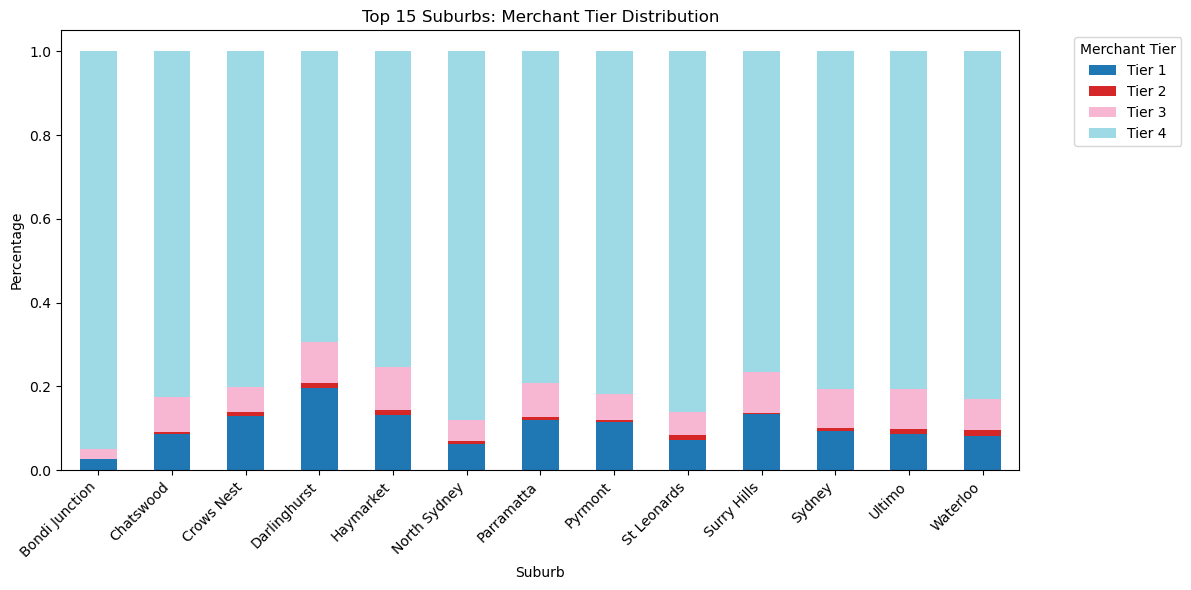

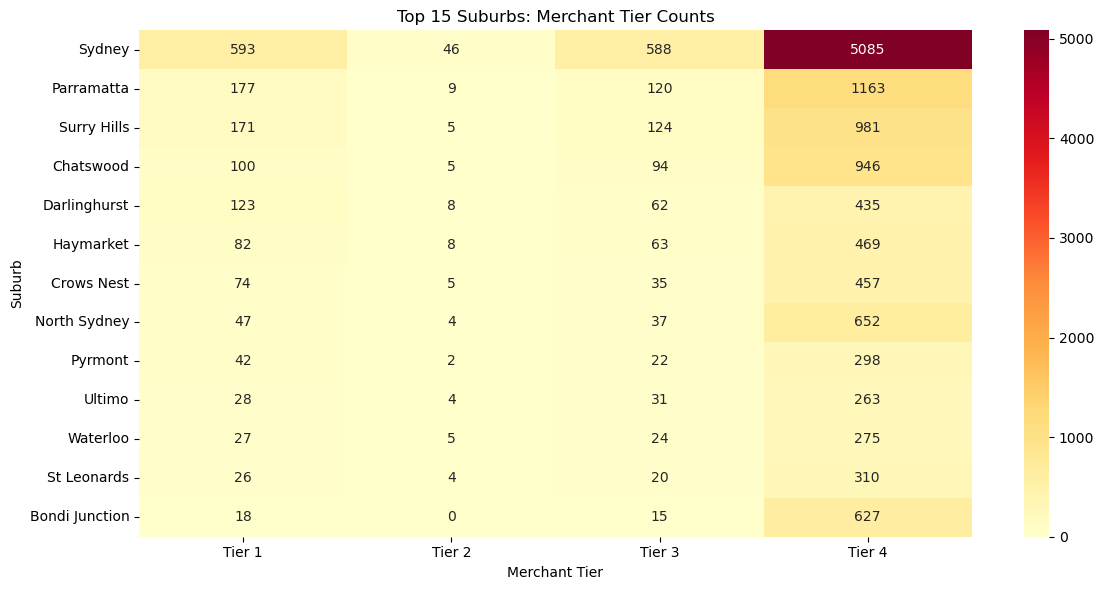

In [19]:
# =========1. Read Data=========
df = pd.read_csv('merchant_with_tier.csv')

# Check required columns
required_cols = ['suburb', 'merchant_tier']
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")


# =========2. Filter Top 15 High-Value Suburbs (based on Tier 1-3 counts)=========

top_tiers = ['Tier 1','Tier 2','Tier 3']
df_top = df[df['merchant_tier'].isin(top_tiers)]
suburb_counts = df_top.groupby('suburb').size().sort_values(ascending=False)
top_suburbs = suburb_counts.head(15).index

df_filtered = df[df['suburb'].isin(top_suburbs)]


# =========3. Stacked Percentage Bar Chart (Tier distribution per suburb)=========
# Create pivot table
pivot = df_filtered.pivot_table(index='suburb', columns='merchant_tier', aggfunc='size', fill_value=0)

# Calculate percentage
pivot_percent = pivot.div(pivot.sum(axis=1), axis=0)

# Plot stacked percentage bar chart
pivot_percent.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')
plt.ylabel('Percentage')
plt.xlabel('Suburb')
plt.title('Top 15 Suburbs: Merchant Tier Distribution')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Merchant Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# =========4. Heatmap (absolute numbers)=========
# Keep Top 15 suburb order
pivot_heat = pivot.loc[top_suburbs]

plt.figure(figsize=(12,6))
sns.heatmap(pivot_heat, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Top 15 Suburbs: Merchant Tier Counts')
plt.xlabel('Merchant Tier')
plt.ylabel('Suburb')
plt.tight_layout()
plt.show()

# Part 3: Performance Dashboard


## 1. Key Metrics (5 KPIs)

| Metric | Description | Reason for Selection |
|--------|------------|--------------------|
| **Total Leads** | Total number of merchants (all Tiers) | Understand overall market size and potential BD leads |
| **Engagement Rate** | Number or proportion of merchants contacted | Measure BD execution efficiency and ensure high-priority merchants are covered |
| **Conversion Rate** | Number or proportion of merchants signed | Evaluate actual sales outcomes and identify sales funnel bottlenecks |
| **Tier Distribution** | Number of merchants in each Tier | Guide BD team to prioritize high-potential merchants (Tier 1–3) |
| **Geographic Distribution** | Number of contacted merchants per Suburb and Tier | Inform regional strategy and optimize visit sequence and efficiency |

> **Note**: Smaller Tier numbers indicate higher priority. BD teams should focus first on Tier 1–3 merchants to maximize KPay product adoption and market coverage.



## 2. KPI Significance

- **Total Leads** – Shows overall market potential for KPay products.  
- **Engagement / Conversion Rates** – Monitor execution efficiency and identify weaknesses in the sales funnel.  
- **Tier Distribution** – Helps allocate resources effectively, focusing on high-value merchants.  
- **Geographic Distribution** – Displays the geographic spread of contacted merchants, optimizing BD visit routes and efficiency.  

> These KPIs cover market potential, execution performance, and sales results, directly aligning with management’s strategic and performance concerns.



## 3. Next Steps Recommendations

### 1. Continuously Track BD Activity Data
- Update `contacted` and `converted` status immediately after each merchant visit or online interaction  
- Record key interaction details, such as visit date, merchant interest level, potential needs, and reasons for non-conversion  
- Update KPIs regularly (e.g., weekly) to track outreach progress and conversion by Tier and Suburb  

### 2. Build a Dynamic Sales Performance Dashboard
- Use Python (Plotly/Dash), Tableau, or Power BI to create an interactive sales dashboard  
- Connect the dashboard to **real BD operational data**, such as CRM visit logs, contact records, and signed merchant data  
- Enable filtering and interactive analysis by **Merchant Tier, Suburb, or Industry Category**  
- Allow sales managers to monitor BD outreach coverage, regional performance, and conversion efficiency in real-time  

### 3. Optimize BD Visits and Resource Allocation
- Allocate BD resources to **high-potential Tier 1–3 merchants** first to maximize sign-up opportunities  
- Analyze engagement and conversion rate differences across Tiers to identify sales bottlenecks  
- Increase BD resources or promotional efforts for Tiers showing higher conversion rates  
- Plan concentrated visits in high-density merchant areas (top Suburbs) to improve efficiency  

### 4. Establish Feedback and Rating Optimization Mechanism
- Collect market feedback during BD visits, including:
  - Merchant interest in KPay products  
  - Current use of alternative payment solutions  
  - Key product features or cost concerns  
- Integrate feedback into the next **Merchant Scoring / Tiering model**  
- Continuously refine merchant scoring rules to make Tier assignment more accurate, improving future BD outreach success

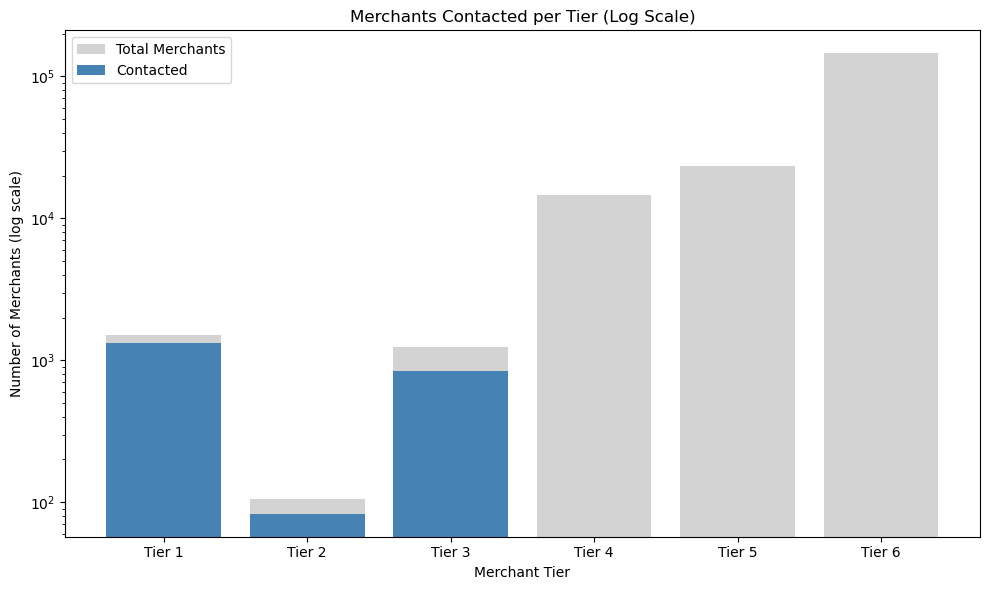

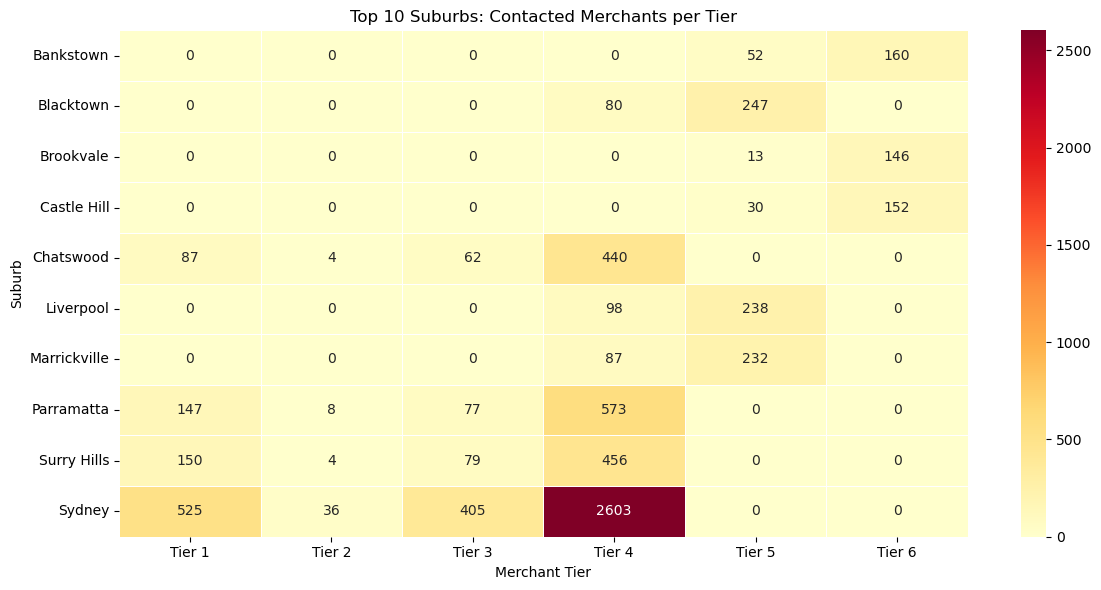

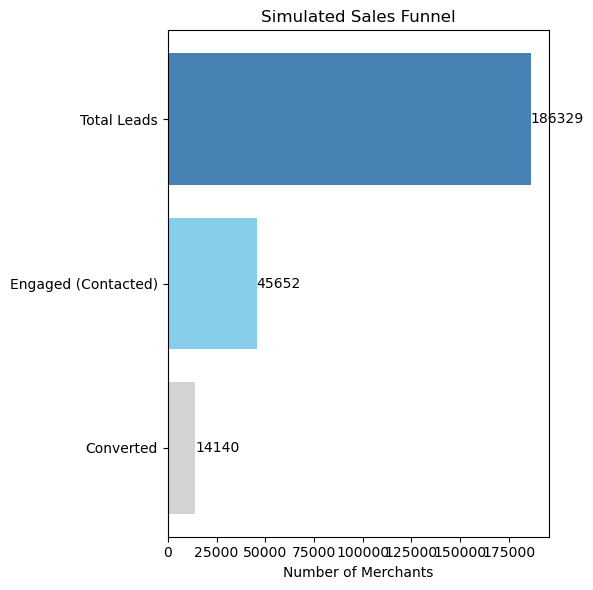

In [20]:
# ========= 1. Load Data =========
# Load the merchant dataset with 'merchant_tier' and 'suburb' columns
df = pd.read_csv('merchant_with_tier.csv')  


# ========= 2. Simulate KPI Data =========
# Set random seed for reproducibility
np.random.seed(42)

# Define simulated contact and conversion rates by merchant tier
tier_contact_rate = {
    'Tier 1': 0.9, 'Tier 2': 0.8, 'Tier 3': 0.7,
    'Tier 4': 0.5, 'Tier 5': 0.3, 'Tier 6': 0.2
}
tier_conversion_rate = {
    'Tier 1': 0.6, 'Tier 2': 0.5, 'Tier 3': 0.4,
    'Tier 4': 0.2, 'Tier 5': 0.1, 'Tier 6': 0.05
}

# Simulate whether each merchant was contacted and converted
df['contacted'] = df['merchant_tier'].map(lambda x: np.random.binomial(1, tier_contact_rate.get(x, 0.3)))
df['converted'] = df['merchant_tier'].map(lambda x: np.random.binomial(1, tier_conversion_rate.get(x, 0.1)))


# ========= 3. Bar Chart (Log Scale) - Merchants per Tier =========
# Summarize total, contacted, and converted merchants per tier
tier_summary = df.groupby('merchant_tier').agg(
    total_merchants=('merchant_tier','count'),
    contacted_merchants=('contacted','sum'),
    converted_merchants=('converted','sum')
).reset_index()

# Define colors: highlight high-priority tiers (1–3) in blue
colors_contacted = ['steelblue' if t in ['Tier 1','Tier 2','Tier 3'] else 'lightgray' for t in tier_summary['merchant_tier']]
colors_total = ['lightgray' for _ in tier_summary['merchant_tier']]

# Plot total and contacted merchants per tier (logarithmic scale)
plt.figure(figsize=(10,6))
plt.bar(tier_summary['merchant_tier'], tier_summary['total_merchants'], color=colors_total, label='Total Merchants')
plt.bar(tier_summary['merchant_tier'], tier_summary['contacted_merchants'], color=colors_contacted, label='Contacted')
plt.yscale('log')
plt.ylabel('Number of Merchants (log scale)')
plt.xlabel('Merchant Tier')
plt.title('Merchants Contacted per Tier (Log Scale)')
plt.legend()
plt.tight_layout()
plt.show()


# ========= 4. Heatmap - Top 10 Suburbs (Contacted Merchants) =========
# Filter out missing or invalid suburb entries
df_suburb = df[df['suburb'].notna()]
df_suburb = df_suburb[~df_suburb['suburb'].astype(str).str.lower().eq('nan')]

# Identify top 10 suburbs by total number of merchants
top_suburbs = df_suburb['suburb'].value_counts().head(10).index

# Filter data for top 10 suburbs
df_top = df_suburb[df_suburb['suburb'].isin(top_suburbs)]

# Create pivot table: rows=suburb, columns=merchant_tier, values=sum of contacted merchants
pivot_contacted = df_top.pivot_table(
    index='suburb',
    columns='merchant_tier',
    values='contacted',
    aggfunc='sum',
    fill_value=0
)

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(
    pivot_contacted,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    cbar=True,
    linewidths=0.5,
    linecolor='white'
)
plt.title('Top 10 Suburbs: Contacted Merchants per Tier')
plt.xlabel('Merchant Tier')
plt.ylabel('Suburb')
plt.tight_layout()
plt.show()


# ========= 5. Funnel Chart - Simulated Engagement → Conversion =========
# Calculate funnel values
total_leads = tier_summary['total_merchants'].sum()
engagement = tier_summary['contacted_merchants'].sum()
conversion = tier_summary['converted_merchants'].sum()

stages = ['Total Leads','Engaged (Contacted)','Converted']
values = [total_leads, engagement, conversion]

# Plot horizontal funnel chart
plt.figure(figsize=(6,6))
plt.barh(stages[::-1], values[::-1], color=['lightgray','skyblue','steelblue'])
plt.xlabel('Number of Merchants')
plt.title('Simulated Sales Funnel')
for i, v in enumerate(values[::-1]):
    plt.text(v + 2, i, str(v), va='center')  # Label each bar
plt.tight_layout()
plt.show()

## Interactive Performance Dashboard (Select Tier)

Need to run the code to Interactive and Select Tier

In [ ]:
# =========1. Load Data=========
df = pd.read_csv("merchant_with_tier.csv")


# =========2. Simulate KPI Data=========
np.random.seed(42)

tier_contact_rate = {
    'Tier 1': 0.9, 'Tier 2': 0.8, 'Tier 3': 0.7,
    'Tier 4': 0.5, 'Tier 5': 0.3, 'Tier 6': 0.2
}

tier_conversion_rate = {
    'Tier 1': 0.6, 'Tier 2': 0.5, 'Tier 3': 0.4,
    'Tier 4': 0.2, 'Tier 5': 0.1, 'Tier 6': 0.05
}

df["contacted"] = df["merchant_tier"].map(
    lambda x: np.random.binomial(1, tier_contact_rate.get(x,0.3))
)

df["converted"] = df["merchant_tier"].map(
    lambda x: np.random.binomial(1, tier_conversion_rate.get(x,0.1))
)


# =========3. Dashboard Function=========
def dashboard(selected_tier):

    if selected_tier != "All":
        data = df[df["merchant_tier"] == selected_tier]
    else:
        data = df.copy()

    # Tier Summary
    tier_summary = data.groupby("merchant_tier").agg(
        total_merchants=("merchant_tier","count"),
        contacted_merchants=("contacted","sum"),
        converted_merchants=("converted","sum")
    ).reset_index()

    # -------------------------------
    # Chart 1 Tier Distribution
    # -------------------------------
    fig1 = px.bar(
        tier_summary,
        x="merchant_tier",
        y=["total_merchants","contacted_merchants"],
        barmode="group",
        title="Merchants per Tier"
    )

    fig1.show()

    # -------------------------------
    # Chart 2 Heatmap
    # -------------------------------
    df_suburb = data[data["suburb"].notna()]
    df_suburb = df_suburb[~df_suburb["suburb"].astype(str).str.lower().eq("nan")]

    top_suburbs = df_suburb["suburb"].value_counts().head(10).index
    df_top = df_suburb[df_suburb["suburb"].isin(top_suburbs)]

    pivot = df_top.pivot_table(
        index="suburb",
        columns="merchant_tier",
        values="contacted",
        aggfunc="sum",
        fill_value=0
    )

    fig2 = px.imshow(
        pivot,
        text_auto=True,
        color_continuous_scale="YlOrRd",
        title="Top Suburbs Contacted Merchants"
    )

    fig2.show()

    # -------------------------------
    # Chart 3 Funnel
    # -------------------------------
    total = tier_summary["total_merchants"].sum()
    contacted = tier_summary["contacted_merchants"].sum()
    converted = tier_summary["converted_merchants"].sum()

    fig3 = go.Figure(go.Funnel(
        y=["Total Leads","Contacted","Converted"],
        x=[total,contacted,converted]
    ))

    fig3.update_layout(title="Sales Funnel")

    fig3.show()


# =========4. Interactive Dropdown=========
tiers = ["All"] + sorted(df["merchant_tier"].dropna().unique())

interact(
    dashboard,
    selected_tier=Dropdown(
        options=tiers,
        value="All",
        description="Select Tier:"
    )
)

interactive(children=(Dropdown(description='Select Tier:', options=('All', 'Tier 1', 'Tier 2', 'Tier 3', 'Tier…

<function __main__.dashboard(selected_tier)>